# Text Classification System Design Practice
## Insurance Claim Text → BI Risk / Routing Classification

This notebook is designed for interview preparation. It simulates a **text-based classification problem** similar to insurance claim triage:

> Given claim text available at intake, predict whether the claim will eventually require bodily injury (BI) specialist involvement.

It covers problem scoping, prediction-time availability, temporal leakage, PII redaction, noisy text, TF-IDF, dense semantic representations, optional transformer embeddings, ranking vs calibration, PR-AUC/ROC-AUC, cost-sensitive evaluation, error analysis, and monitoring.

Run it cell by cell and practice explaining the **Interview Talk Track** sections out loud.

## Setup

Install:

```bash
pip install pandas numpy scikit-learn matplotlib
```

Optional:

```bash
pip install sentence-transformers
```

The optional transformer section is off by default.

In [1]:
import re, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score, recall_score,
    average_precision_score, roc_auc_score, roc_curve, precision_recall_curve,
    brier_score_loss, log_loss
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
RANDOM_STATE=42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 160)

# Stage 1 — Problem Scoping

**Business problem:** Route claims likely to require BI specialist involvement as early as possible.

**Target label:** `label_bi = 1` means the claim eventually required BI specialist involvement; `0` means it did not.

**Important nuance:** The label is observed later. That is okay for supervised learning. The key is that the **features/text** must only use information available at prediction time.

**Interview Talk Track:**
> The label may be determined in the future, but that is acceptable because labels are used for supervised learning. The important question is whether the input text and features would have been available at the prediction time.

# Stage 2 — Create synthetic claim text data

Real insurance claim text is hard to find publicly because of privacy and sensitivity. This notebook generates synthetic claim descriptions with:

- `initial_claim_text`: available at claim intake
- `early_agent_note`: available around intake
- `later_adjuster_note`: created later and intentionally leaky
- `label_bi`: target
- state, claim type, text quality

In [2]:
positive_templates=[
    "Rear-end collision. Claimant reports neck pain and plans to visit urgent care.",
    "Driver says their back hurts after the crash. Passenger also complained of pain.",
    "Customer reported shoulder injury after impact. Ambulance was mentioned at the scene.",
    "T-bone accident at intersection. Claimant went to hospital for evaluation.",
    "Customer says they feel dizzy and have headache after airbag deployment.",
    "Passenger reports whiplash symptoms after being hit from behind.",
    "Claimant states they may need physical therapy for back and neck pain.",
    "Severe impact. Driver reports pain and medical treatment may be needed.",
    "Customer said they were injured and requested information about medical coverage.",
    "Accident involved high speed impact. Claimant reports chest pain after crash."
]
negative_templates=[
    "Minor bumper scratch in parking lot. No injury reported.",
    "Vehicle was hit while parked. Customer reports property damage only.",
    "Low speed sideswipe. No pain or medical treatment mentioned.",
    "Rear bumper damage only. Driver says everyone is okay.",
    "Customer reports cracked tail light. No ambulance and no injury.",
    "Small fender bender. Vehicle still drivable. No bodily injury reported.",
    "Customer says there was no pain, no injury, and no medical attention needed.",
    "Mirror damage from lane change incident. Property damage only.",
    "Minor collision at stop sign. No one was hurt.",
    "Customer reports scratch on door. No injury concerns at this time."
]
ambiguous_templates=[
    "Customer is unsure if they are injured but reports stiffness after the accident.",
    "No injury reported at the scene, but customer may call back if pain develops.",
    "Customer mentioned soreness but did not seek medical care yet.",
    "Claimant said they felt okay initially but woke up with mild back discomfort.",
    "Police report pending. Customer mentioned possible neck stiffness."
]
states=["GA","IL","TX","AZ","OH","CA","FL","NY"]
claim_types=["rear_end","intersection","parking_lot","sideswipe","single_vehicle","hit_while_parked"]
text_quality=["clear","terse","noisy","limited_english"]

def add_pii(text):
    if random.random()<0.25:
        text += f" Customer phone ({random.randint(200,999)}) {random.randint(200,999)}-{random.randint(1000,9999)}."
    if random.random()<0.18:
        text += f" Address {random.randint(100,9999)} {random.choice(['Main St','Peachtree Rd','Oak Ave','Maple Dr','Highland Blvd'])}."
    if random.random()<0.10:
        text += f" Contact name {random.choice(['John Smith','Maria Garcia','David Lee','Sarah Johnson'])}."
    return text

def add_noise(text):
    repl={"injury":"injry","hospital":"hosp","ambulance":"amb","physical therapy":"PT","customer":"cust","reported":"rptd","accident":"accdnt","vehicle":"veh","damage":"dmg","collision":"collsn","medical":"med"}
    for k,v in repl.items():
        if random.random()<0.25:
            text=text.replace(k,v).replace(k.title(),v)
    if random.random()<0.20:
        text=text.lower()
    return text

def generate_claim(i):
    label_bi=np.random.binomial(1,0.15)
    ambiguous=False
    if label_bi:
        text=random.choice(positive_templates)
        if random.random()<0.20:
            text=random.choice(ambiguous_templates); ambiguous=True
    else:
        text=random.choice(negative_templates)
        if random.random()<0.12:
            text=random.choice(ambiguous_templates); ambiguous=True
    state=random.choice(states); ctype=random.choice(claim_types); quality=random.choice(text_quality)
    if quality=="terse":
        text=random.choice([
            "rear end. neck pain." if label_bi else "minor dmg. no injury.",
            "hit from behind. sore." if label_bi else "parked car hit. pd only.",
            "went to er." if label_bi else "bumper only. ok."
        ])
    elif quality=="limited_english":
        text=random.choice([
            "car hit me. my neck pain. doctor maybe." if label_bi else "small hit. no hurt. car damage only.",
            "back pain after accident." if label_bi else "no pain. only car scratch.",
            "passenger hurt maybe hospital." if label_bi else "all okay no injury."
        ])
    elif quality=="noisy":
        text=add_noise(text)
    if label_bi:
        later_note=random.choice([
            "BI specialist assigned after injury was confirmed.",
            "Medical treatment documented. Bodily injury exposure opened.",
            "Attorney letter received. BI team handling claim.",
            "Claimant began treatment and BI reserve was created."
        ])
    else:
        later_note=random.choice([
            "PD-only claim closed. No BI exposure.",
            "No medical treatment reported. General handler closed claim.",
            "Property damage only. No injury follow-up.",
            "Claim resolved without BI specialist involvement."
        ])
    return {
        "claim_id":f"C{i:05d}","state":state,"claim_type":ctype,
        "text_quality":quality,"initial_claim_text":add_pii(text),
        "early_agent_note":random.choice([
            "FNOL completed. Initial facts recorded.",
            "Claim intake completed. Photos may be requested.",
            "Agent captured initial loss description.",
            "Initial contact completed. Coverage check pending."
        ]),
        "later_adjuster_note":later_note,"label_bi":label_bi,"ambiguous_text":ambiguous
    }

df=pd.DataFrame([generate_claim(i) for i in range(3000)])
display(df.head())
display(df["label_bi"].value_counts(normalize=True).rename({0:"Non-BI",1:"BI"}))

,claim_id,state,claim_type,text_quality,initial_claim_text,early_agent_note,later_adjuster_note,label_bi,ambiguous_text
0,C00000,AZ,intersection,terse,bumper only. ok. Contact name Sarah Johnson.,FNOL completed. Initial facts recorded.,PD-only claim closed. No BI exposure.,0,True
1,C00001,GA,single_vehicle,terse,went to er. Customer phone (803) 484-1106.,Initial contact completed. Coverage check pending.,Claimant began treatment and BI reserve was created.,1,True
2,C00002,AZ,parking_lot,clear,Small fender bender. Vehicle still drivable. No bodily injury reported.,Agent captured initial loss description.,PD-only claim closed. No BI exposure.,0,False
3,C00003,IL,sideswipe,clear,Minor bumper scratch in parking lot. No injury reported.,Claim intake completed. Photos may be requested.,Property damage only. No injury follow-up.,0,False
4,C00004,OH,rear_end,terse,minor dmg. no injury.,Agent captured initial loss description.,Claim resolved without BI specialist involvement.,0,True


label_bi
Non-BI    0.847
BI        0.153
Name: proportion, dtype: float64

In [3]:
df['claim_type'].unique()

array(['intersection', 'single_vehicle', 'parking_lot', 'sideswipe',
       'rear_end', 'hit_while_parked'], dtype=object)

In [4]:
df['text_quality'].unique()

array(['terse', 'clear', 'noisy', 'limited_english'], dtype=object)

In [5]:
df[df['text_quality'] == 'noisy'].sample(5)

,claim_id,state,claim_type,text_quality,initial_claim_text,early_agent_note,later_adjuster_note,label_bi,ambiguous_text
2810,C02810,FL,rear_end,noisy,Mirror damage from lane change incident. Property damage only.,FNOL completed. Initial facts recorded.,Property damage only. No injury follow-up.,0,False
1151,C01151,IL,hit_while_parked,noisy,Minor collision at stop sign. No one was hurt.,Initial contact completed. Coverage check pending.,Claim resolved without BI specialist involvement.,0,False
2320,C02320,NY,intersection,noisy,Police report pending. Customer mentioned possible neck stiffness.,Claim intake completed. Photos may be requested.,Claimant began treatment and BI reserve was created.,1,True
1405,C01405,AZ,sideswipe,noisy,small fender bender. vehicle still drivable. no bodily injry rptd.,Agent captured initial loss description.,PD-only claim closed. No BI exposure.,0,False
34,C00034,GA,parking_lot,noisy,Accident involved high speed impact. Claimant reports chest pain after crash.,FNOL completed. Initial facts recorded.,Claimant began treatment and BI reserve was created.,1,False


In [6]:
df[df['text_quality'] == 'clear'].sample(5)

,claim_id,state,claim_type,text_quality,initial_claim_text,early_agent_note,later_adjuster_note,label_bi,ambiguous_text
1260,C01260,OH,single_vehicle,clear,Customer reports scratch on door. No injury concerns at this time. Customer phone (608) 810-3336.,Initial contact completed. Coverage check pending.,Property damage only. No injury follow-up.,0,False
953,C00953,AZ,rear_end,clear,Customer said they were injured and requested information about medical coverage.,FNOL completed. Initial facts recorded.,BI specialist assigned after injury was confirmed.,1,False
2004,C02004,CA,intersection,clear,Rear bumper damage only. Driver says everyone is okay. Address 9279 Main St.,FNOL completed. Initial facts recorded.,Claim resolved without BI specialist involvement.,0,False
2268,C02268,GA,hit_while_parked,clear,Claimant said they felt okay initially but woke up with mild back discomfort. Customer phone (572) 354-3079.,Agent captured initial loss description.,Claim resolved without BI specialist involvement.,0,True
983,C00983,GA,parking_lot,clear,Customer reports scratch on door. No injury concerns at this time.,Agent captured initial loss description.,Property damage only. No injury follow-up.,0,False


## Stage 2A — Prediction-time availability

Ask: **Could we know this text at the moment the model makes the prediction?**

In [7]:
availability_table=pd.DataFrame({
    "text_source":["initial_claim_text","early_agent_note","later_adjuster_note"],
    "available_at_claim_intake":[True,True,False],
    "use_for_early_routing_model":[True,True,False],
    "reason":["Customer-provided description at intake.","Early operational note available around intake.","Created later and may directly reveal BI outcome."]
})
display(availability_table)

,text_source,available_at_claim_intake,use_for_early_routing_model,reason
0,initial_claim_text,True,True,Customer-provided description at intake.
1,early_agent_note,True,True,Early operational note available around intake.
2,later_adjuster_note,False,False,Created later and may directly reveal BI outcome.


## Stage 2B — PII redaction

Claim text may contain names, phone numbers, or addresses. In production, define a PII handling strategy before modeling.

In [8]:
def redact_pii(text):
    text=re.sub(r"\(\d{3}\)\s?\d{3}-\d{4}","[PHONE]",text)
    text=re.sub(r"\b\d{2,5}\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?\s+(?:St|Rd|Ave|Dr|Blvd)\b","[ADDRESS]",text)
    for name in ["John Smith","Maria Garcia","David Lee","Sarah Johnson"]:
        text=text.replace(name,"[NAME]")
    return text

df["initial_text_redacted"]=df["initial_claim_text"].apply(redact_pii)
display(df[["initial_claim_text","initial_text_redacted"]].sample(8,random_state=RANDOM_STATE))

,initial_claim_text,initial_text_redacted
1801,no pain. only car scratch. Address 9102 Highland Blvd.,no pain. only car scratch. Address [ADDRESS].
1190,Mirror damage from lane change incident. Property damage only. Address 4263 Oak Ave.,Mirror damage from lane change incident. Property damage only. Address [ADDRESS].
1817,Customer reports cracked tail light. No amb and no injry. Customer phone (353) 223-8864.,Customer reports cracked tail light. No amb and no injry. Customer phone [PHONE].
251,parked car hit. pd only.,parked car hit. pd only.
2505,no pain. only car scratch.,no pain. only car scratch.
1117,went to er.,went to er.
1411,parked car hit. pd only.,parked car hit. pd only.
2113,Claimant said they felt okay initially but woke up with mild back discomfort.,Claimant said they felt okay initially but woke up with mild back discomfort.


# Stage 3 — TF-IDF Feature Engineering

TF-IDF creates a document-by-word matrix. Rows are claim texts, columns are terms, and values are term importance.

,claim_text,address,car,change,change incident,contact,customer,customer phone,damage,damage lane,incident,lane,lane change,mentioned,phone,phone phone
0,Rear bumper damage only. Driver says everyone is okay. Customer phone [PHONE]. Address [ADDRESS]. Contact name [NAME].,0.62,0.00,0.00,0.00,0.31,0.21,0.27,0.23,0.00,0.00,0.00,0.00,0.00,0.53,0.27
1,Mirror damage from lane change incident. Property damage only. Customer phone [PHONE].,0.00,0.00,0.28,0.28,0.00,0.18,0.24,0.42,0.28,0.28,0.28,0.28,0.00,0.47,0.24
2,Customer mentioned soreness but did not seek med care yet. Contact name [NAME].,0.00,0.00,0.00,0.00,0.64,0.43,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00
3,minor dmg. no injury.,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Customer reported shoulder injury after impact. Ambulance was mentioned at the scene. Address [ADDRESS].,0.86,0.00,0.00,0.00,0.00,0.29,0.00,0.00,0.00,0.00,0.00,0.00,0.43,0.00,0.00
5,no pain. only car scratch. Customer phone [PHONE].,0.00,0.41,0.00,0.00,0.00,0.28,0.35,0.00,0.00,0.00,0.00,0.00,0.00,0.71,0.35
6,small hit. no hurt. car damage only.,0.00,0.80,0.00,0.00,0.00,0.00,0.00,0.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,Mirror damage from lane change incident. Property damage only.,0.00,0.00,0.35,0.35,0.00,0.00,0.00,0.53,0.35,0.35,0.35,0.35,0.00,0.00,0.00


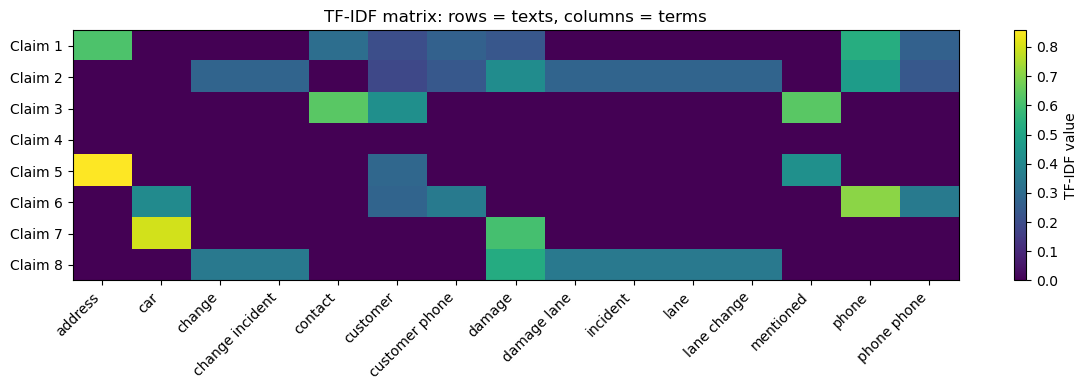

In [19]:
tfidf_demo=TfidfVectorizer(max_features=15,ngram_range=(1,2),stop_words="english")
sample_texts=df["initial_text_redacted"].sample(8,random_state=7).tolist()
X_demo=tfidf_demo.fit_transform(sample_texts)
tfidf_table=pd.DataFrame(X_demo.toarray(),columns=tfidf_demo.get_feature_names_out())
tfidf_table.insert(0,"claim_text",sample_texts)
display(tfidf_table.round(2))

features=tfidf_demo.get_feature_names_out(); matrix=X_demo.toarray()
plt.figure(figsize=(12,4)); plt.imshow(matrix,aspect="auto"); plt.colorbar(label="TF-IDF value")
plt.xticks(range(len(features)),features,rotation=45,ha="right")
plt.yticks(range(len(sample_texts)),[f"Claim {i+1}" for i in range(len(sample_texts))])
plt.title("TF-IDF matrix: rows = texts, columns = terms")
plt.tight_layout(); plt.show()

### **Inverse Document Frequency (IDF)**
**IDF penalizes overly frequent words to capture the truly important, meaningful words from a document.**

* **The Concept:** Words that appear in almost *every* document (like "the", "and", or "accident") are not helpful for distinguishing one text from another. IDF lowers the weight of these common words and boosts the weight of rare, unique words.
* **The Formula:**

$$IDF(t) = \log\left(\frac{N}{df(t)}\right)$$

* $N$: Total number of documents.
* $df(t)$: Document Frequency (The number of documents containing the term $t$).

> **💡 Key Takeaway:** If a word appears in every single document ($df(t) = N$), the fraction becomes 1. Since $\log(1) = 0$, the word's importance score drops to zero!

# Stage 3B —  Latent Semantic Analysis - transforming hign dimensional sparse vector to dense vector (through TruncatedSVD)
- Embedding dimensions are not interpretable word columns. Similar meanings should be close together. Here we use TF-IDF + SVD to visualize a simple dense and latent semantic space. This is not a neural embedding, but it makes the idea concrete.
  - 임베딩(Embedding)이란? 컴퓨터가 이해할 수 있도록 단어나 문장을 숫자(좌표)로 바꾸는 것
  - **사과: [0.9, 0.1, -0.5]**
  - **배: [0.8, 0.2, -0.4] (사과와 숫자가 비슷함)**
  - **자동차: [-0.2, 0.9, 0.8] (사과와 숫자가 전혀 다름)**

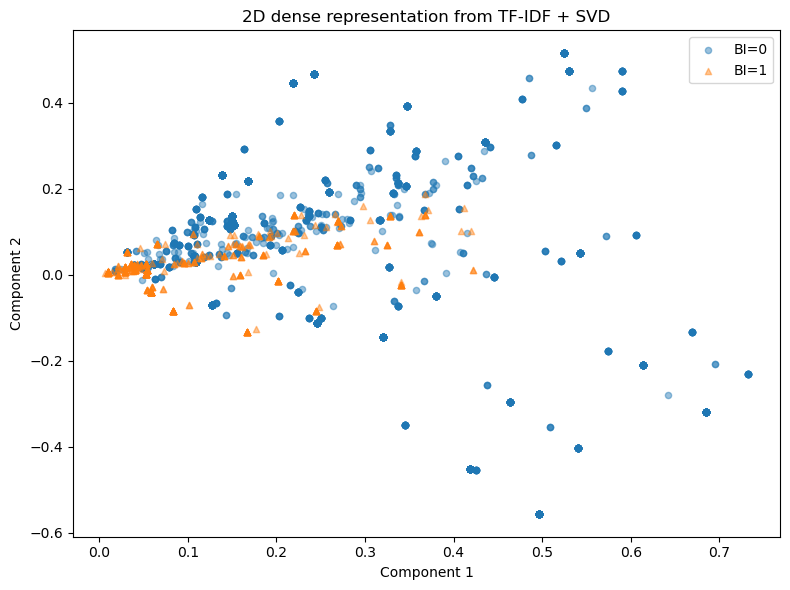

In [9]:
tfidf_full=TfidfVectorizer(max_features=1000,ngram_range=(1,2),stop_words="english",min_df=3)
X_tfidf_full=tfidf_full.fit_transform(df["initial_text_redacted"])
svd2=TruncatedSVD(n_components=2,random_state=RANDOM_STATE)
X_2d=svd2.fit_transform(X_tfidf_full)
plot_df=pd.DataFrame({"x":X_2d[:,0],"y":X_2d[:,1],"label_bi":df["label_bi"]})
plt.figure(figsize=(8,6))
for label,marker in [(0,"o"),(1,"^")]:
    sub=plot_df[plot_df["label_bi"]==label]
    plt.scatter(sub["x"],sub["y"],alpha=0.45,s=20,marker=marker,label=f"BI={label}")
plt.title("2D dense representation from TF-IDF + SVD")
plt.xlabel("Component 1"); plt.ylabel("Component 2"); plt.legend(); plt.tight_layout(); plt.show()

- 데이터 내에서 가장 큰 변동성(Variance)을 가지는 방향을 1번(X축), 그 다음으로 큰 변동성을 가진 방향을 2번(Y축)으로 찾아낸 것
- X, Y 축들은 "보험금의 크기"나 "부상의 심각도"처럼 직관적인 개념이 아니라, 수천 개의 단어 빈도 분포를 수학적으로 가장 잘 설명하는 추상적인 조합, 해석상의 큰 의미는 없음.
- 텍스트의 '맥락(Context)'을 이해하지 못하고 '단어의 겹침' 즉, 텍스트의 통계적 빈도(Surface level features) 중심으로 판단. 따라서 데이터가 평면상에 넓게 퍼져 뚜렷한 군집이 잘 생기지 않음.

### 💡 Concept Check: Is TF-IDF + SVD an "Embedding"?

Yes, in a broad sense, it is a **Classical/Statistical Embedding**. 

* **The Problem:** Raw TF-IDF creates a massive, **Sparse Matrix** where every unique word becomes its own dimension. 
* **The Solution (SVD):** Applying **TruncatedSVD** (Singular Value Decomposition) compresses this high-dimensional space into a low-dimensional **Dense Vector** (e.g., shrinking 1,000+ word dimensions down to just 2 or 100).
  - "데이터의 핵심 정보량(Singular Value)을 뽑아내어(Decomposition) 복잡한 데이터를 단순하게 해체하는 방법"
* **The History:** In traditional NLP, this technique is widely known as **LSA (Latent Semantic Analysis)**. It groups words that frequently appear together into hidden, "latent" topics.

---

### 🎙️ Interview Talk Track: Why use TF-IDF + SVD as a Baseline?

> *"Yes, TF-IDF + SVD is a classical, statistical method to generate **Dense Embeddings** by compressing a high-dimensional sparse space into a **Latent Semantic Space**."*
>
> *"While modern deep learning models—like BERT or Sentence-Transformers—are far better at capturing complex context and word order, this classical approach has a massive operational advantage."*
>
> *"It computes instantly **without a GPU** and costs almost nothing to serve in production. Therefore, when designing large-scale systems, it serves as a highly efficient, lightweight **Baseline** to validate our pipeline before investing in expensive neural network infrastructure."*

## Optional: Transformer / sentence embeddings

Turn this on only if you have internet and want to download a model. A sentence transformer creates neural embeddings where semantically similar claim descriptions are close together.

In [ ]:
# 허깅페이스 필수 패키지 설치
# !pip install datasets transformers accelerate

Batches: 100%|██████████| 16/16 [00:00<00:00, 39.20it/s]


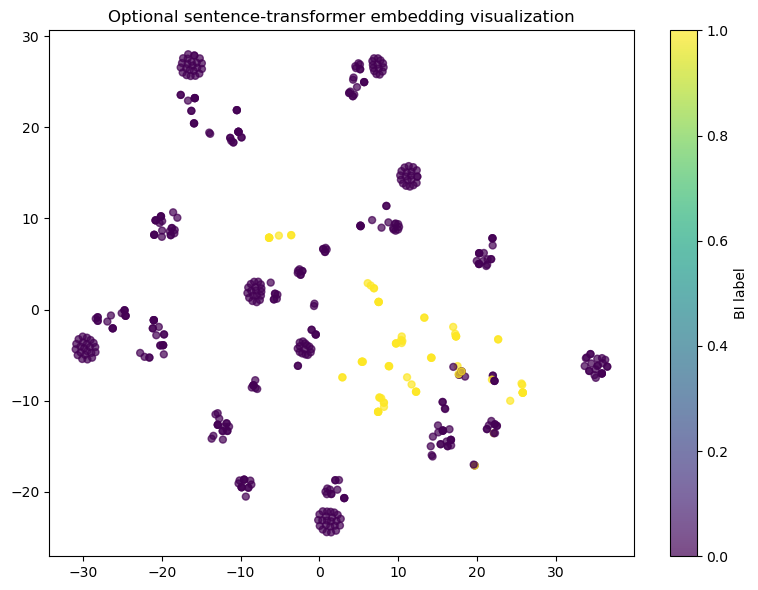

In [12]:
RUN_SENTENCE_TRANSFORMER=True # False to evaluate a lightweight TF-IDF + Linear Model baseline to see what score we can achieve with minimal compute.
if RUN_SENTENCE_TRANSFORMER:
    from sentence_transformers import SentenceTransformer
    from sklearn.manifold import TSNE
    model=SentenceTransformer("all-MiniLM-L6-v2")
    sample=df.sample(500,random_state=RANDOM_STATE).copy()
    emb=model.encode(sample["initial_text_redacted"].tolist(),show_progress_bar=True)
    emb_2d=TSNE(n_components=2,random_state=RANDOM_STATE,init="random",learning_rate="auto").fit_transform(emb)
    plt.figure(figsize=(8,6)); plt.scatter(emb_2d[:,0],emb_2d[:,1],c=sample["label_bi"],alpha=0.7,s=25)
    plt.title("Optional sentence-transformer embedding visualization"); plt.colorbar(label="BI label"); plt.tight_layout(); plt.show()
else:
    print("Optional transformer section skipped. Set RUN_SENTENCE_TRANSFORMER = True to run it.")

- 이 모델은 수억 개의 문장으로 사전 학습된 인공지능(BERT 계열)을 활용, 비슷한 의미를 가진 청구 건들을 수학적 공간에서 더 좁은 범위로 꽉 뭉치게(Embedding) 할 수 있음.
  - BERT(Bidirectional Encoder Representations from Transformers): 문맥을 좌우 앞뒤로 한꺼번에 읽는 똑똑한 읽기 능력
  - Sentence-Transformer는 BERT가 이미 학습한 "언어 이해력"을 숫자 벡터(임베딩)로 아주 잘 요약해서 뽑아내 주는, BERT의 진화된 버전

### 🎙️ Interview Talk Track: Moving from TF-IDF to Transformer Embeddings

> *"Once the lightweight TF-IDF baseline is established, the next logical upgrade is to leverage a pre-trained Deep Learning model, such as `Sentence-Transformer` (e.g., `all-MiniLM-L6-v2`)."*
>
> *"While TF-IDF only tracks exact keyword matches and frequencies, Transformers capture **true semantic meaning and context**. For instance, expressions like 'neck pain' and 'cervical discomfort' share no common words, but a Transformer maps them closely together in the dense vector space."*
>
> *"In production, this shift resolves the issue of vocabulary mismatch and human typos in messy claim texts. However, it introduces a trade-off: it requires significantly more compute (ideally a GPU) and increases inference latency compared to our instant TF-IDF + SVD baseline."*

### 📈 System Design Strategy: Iterative Model Development

When presenting this project in an interview, I follow an **iterative development framework**:

1. **Phase 1 (Establish Baseline):** Run the pipeline with `RUN_SENTENCE_TRANSFORMER = False`. This evaluates a lightweight, cost-effective TF-IDF + Linear Model baseline to see what score we can achieve with minimal compute.
2. **Phase 2 (Incorporate Context):** Flip the switch to `RUN_SENTENCE_TRANSFORMER = True` to extract dense semantic vectors. Then, re-run Stage 4 to see if the semantic understanding of the Transformer yields a significant lift in Precision/Recall.
3. **The Decision Matrix:** If the Transformer model improves the F1-score or PR-AUC by a large margin (e.g., > 5-10%), the higher serving infrastructure cost is justified. If the lift is negligible, we stick with the production-friendly TF-IDF baseline.

## Stage 4 — Modeling Approach

We build TF-IDF + Logistic Regression, Random Forest, and XGBoost models as baselines, followed by a Transformer-based embedding model using XGBoost.

**Interview Talk Track:**
> I start with TF-IDF plus various models (Logistic Regression, Random Forest, XGBoost) as lightweight baselines because they are fast and interpretable. Then, I move to transformer-based embeddings (using Sentence-Transformers) to capture richer semantic context, evaluating if the lift in performance justifies the increased infrastructure complexity.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

# 1. Data Splitting
X = df["initial_text_redacted"]
y = df["label_bi"]
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# 2. Pipeline and Model Definitions
logit_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words="english", min_df=3)), #feature extraction
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)) #classification
])

rf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words="english", min_df=3)), #feature extraction
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)) #classification
])

xgb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words="english", min_df=3)), #feature extraction
    ("clf", XGBClassifier(scale_pos_weight=5.5, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)) #classification
])

# 3. Train TF-IDF Based Models and Extract Predicted Probabilities
logit_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train)

logit_proba = logit_pipe.predict_proba(X_test)[:, 1]
rf_proba    = rf_pipe.predict_proba(X_test)[:, 1]
xgb_proba   = xgb_pipe.predict_proba(X_test)[:, 1]


# 4. Generate Transformer Embeddings (XGboost only:'트리 기반 모델'이 텍스트 임베딩의 비선형적인 패턴을 잡아내는 데 더 강력)
print("Generating Transformer Embeddings using RTX 5060 Laptop GPU...")
emb_model = SentenceTransformer("all-MiniLM-L6-v2") # Automatically detects and utilizes CUDA (GPU)
X_embeddings = emb_model.encode(df["initial_text_redacted"].tolist(), show_progress_bar=True)

# Slice the generated embeddings into train and test sets using indices
X_train_emb = X_embeddings[idx_train]
X_test_emb  = X_embeddings[idx_test]

# Train the embedding-based XGBoost model
xgb_emb_model = XGBClassifier(scale_pos_weight=5.5, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)
xgb_emb_model.fit(X_train_emb, y_train)

# Extract predicted probabilities for the embedding-based XGBoost
xgb_emb_proba = xgb_emb_model.predict_proba(X_test_emb)[:, 1]


print("All models fitted and predictions generated successfully!")

Generating Transformer Embeddings using RTX 5060 Laptop GPU...


Batches: 100%|██████████| 94/94 [00:00<00:00, 134.28it/s]


All models fitted and predictions generated successfully!


### 🎙️ Interview Talk Track: Two Ways to Implement Transformer Models

When discussing "Transformer-based models" for text classification, I consider two deployment architectures depending on compute constraints:

1. **Feature Extraction Approach (Used in this notebook):** We use a pre-trained model like `all-MiniLM-L6-v2` as a frozen downstream tool purely to generate 384-dimensional dense vectors. We then pass these high-quality features into a traditional, fast classifier like **Random Forest** or **Logistic Regression**. This keeps training fast and lightweight while upgrading our text representation.
    - all-MiniLM-L6-v2는 이미 엄청난 양의 언어 공부를 마친 '똑똑한 요약 모델(BERT 계열)'
    - Frozen(얼려두다): 이 요약 모델의 머릿속(학습된 지식)을 건드리지 않고, 있는 그대로의 기능만 빌려씀. 학습 과정에서 이 모델은 다시 공부하지 않으니 속도가 빠름.
    - 긴 문장을 넣으면, 이 똑똑한 모델이 문장의 핵심 의미를 딱 384개의 숫자 세트로 압축해서 뱉어줌. 이게 바로 우리가 흔히 말하는 '임베딩(Embedding)'
    - 384개의 숫자가 된 문장 정보를, 계산이 매우 빠른 XGBoost 같은 수학적 분류기에게 던져줌.
      - all-MiniLM-L6-v2라는 모델은 내부적으로 문장을 분석한 결과를 딱 384개의 숫자로 출력하도록 만들어짐.

3. **End-to-End Fine-Tuning Approach:** We take a model like BERT or RoBERTa, add a classification head on top, and train the entire network weights on our insurance claim dataset. This yields the highest accuracy and handles domain-specific nuances best, but requires a dedicated GPU infrastructure for both training and real-time production inference.

# Stage 5. Cross-validation

- Text classification still uses familiar validation ideas: train/test split, stratified k-fold cross-validation, class-imbalance-aware metrics, and threshold tuning on validation data.
- Cross-validation ensures generalization performance. Beyond just metrics, it assesses model stability by checking performance variance across splits. Crucially, it acts as a safeguard against data leakage by allowing parameter tuning without ever touching the final test set.

## Stage 5-A. Cross-validation : Logistic model

In [14]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
scoring={"pr_auc":"average_precision","roc_auc":"roc_auc","recall":"recall","precision":"precision"}
cv_results=cross_validate(logit_pipe,X,y,cv=cv,scoring=scoring,n_jobs=1)
display(pd.DataFrame(cv_results).filter(like="test_").agg(["mean","std"]).T.round(3))

,mean,std
test_pr_auc,0.986,0.005
test_roc_auc,0.997,0.001
test_recall,0.969,0.025
test_precision,0.783,0.030


### 📊 Interpretation of Cross-Validation Results

We utilized **5-Fold Stratified Cross-Validation** to evaluate the robust performance of our baseline model. 

* **Why Stratified?** Since Bodily Injury ($BI=1$) claims are highly imbalanced, stratification ensures that the minority class ratio remains identical across all 5 folds, preventing data shifting issues.
* **What does `std` tell us?** The standard deviation across all metrics is extremely low (e.g., `test_precision std = 0.030`). This proves that our model is highly **stable** and not overfitting to a specific subset of data.

---

### 🎙️ Interview Talk Track: Analyzing the Metrics

> *"Looking at the 5-fold cross-validation results, the model achieves a stellar **Recall of 96.9%**, meaning it catches almost all high-risk bodily injury claims. The **Precision is slightly lower at 78.3%**, which is a classic trade-off when handling imbalanced data."*
>
> *"In the insurance domain, the cost of missing a serious bodily injury claim (False Negative) is much higher than manually reviewing a false alarm (False Positive). Therefore, this high-recall characteristic is highly desirable for our automated routing system."*
>
> *"Furthermore, the **PR-AUC of 0.986** with a tiny standard deviation confirms that this lightweight baseline provides an exception

## Stage 5-B. Cross-validation : Transformer-based model

In [16]:
X_embeddings 
# 3000 (행, Row): 당신이 가진 보험 청구서 데이터의 총 개수입니다. (3000개의 청구서 각각이 row 하나씩을 차지합니다.)
# 384 (열, Column): Sentence-Transformer 모델(all-MiniLM-L6-v2)이 문장 하나를 표현하기 위해 사용하는 숫자의 개수입니다.

array([[-0.07289616,  0.08705765,  0.00614206, ...,  0.02519402,
         0.01964209,  0.09391748],
       [-0.029017  ,  0.01099949,  0.00574862, ...,  0.05957741,
        -0.08447257,  0.03080841],
       [-0.00783237,  0.11556229,  0.07413514, ...,  0.03038015,
         0.04445898,  0.01967701],
       ...,
       [-0.01970333,  0.02329762,  0.05449741, ..., -0.08268046,
         0.07148679,  0.01838324],
       [-0.01970333,  0.02329762,  0.05449741, ..., -0.08268046,
         0.07148679,  0.01838324],
       [ 0.04241764,  0.06067003,  0.05814873, ..., -0.01465162,
         0.03074569,  0.0551332 ]], shape=(3000, 384), dtype=float32)

In [17]:
# 1. Pre-extract embeddings from the entire dataset using the Transformer (Outside CV loop-뽑힌 embeding을 그대로 씀)
# SentenceTransformer only performs encode() without needing to call fit()
X_embeddings = model.encode(X.tolist()) 

# 2. Define the standalone classifier (This is NOT a TF-IDF pipeline)
clf = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)

# 3. Perform Cross-Validation using the pre-extracted embeddings (X_embeddings)
cv_results_transformer = cross_validate(clf, X_embeddings, y, cv=cv, scoring=scoring)

# Display the mean and standard deviation of the test metrics
display(pd.DataFrame(cv_results_transformer).filter(like="test_").agg(["mean","std"]).T.round(3))

,mean,std
test_pr_auc,0.987,0.005
test_roc_auc,0.997,0.001
test_recall,0.978,0.015
test_precision,0.786,0.034


### 🎙️ Interview Talk Track: Feature Extraction with Cross-Validation

When discussing "Transformer-based models" for text classification under strict compute or timeline constraints, I consider the **Feature Extraction** pipeline with out-of-loop Cross-Validation as a highly efficient architecture:

* **Decoupled Representation Learning:** We utilize a pre-trained Transformer like `all-MiniLM-L6-v2` purely as a frozen feature extractor. By running `.encode()` **outside** the Cross-Validation loop, we generate the 384-dimensional dense vectors exactly once for the entire dataset, completely eliminating redundant deep-learning forward passes.
* **Downstream Cross-Validation ($K\text{-Fold}$):** We then feed these fixed contextual embeddings into a traditional, lightweight classifier like `LogisticRegression` to safely run stratified cross-validation.

---

### 💡 Why Use This Design? (Engineering Value)

> *"By decoupling feature extraction from classification, we can rigorously evaluate model variance and average test metrics across multiple folds in **mere seconds** on standard CPU infrastructure."*
> *"This architectural choice allows us to capture deep semantic nuances from state-of-the-art architectures without incurring the heavy GPU overhead, high latency, and cloud infrastructure costs associated with iterative fine-tuning."*
 - 모델을 한 번 학습할 때마다 무거운 GPU를 돌려야 한다면, 교차 검증(CV)을 여러 번 돌리는 것은 엄청나게 느릴 것입니다. 하지만 이미 특징(임베딩)을 다 뽑아놓고 분류기만 학습시키면, 검증 루프가 거의 실시간(초 단위)으로 돌아갑니다. 즉, "우리 모델이 진짜 믿을만한가?"를 확인하는 테스트를 매우 빠르고 자주 할 수 있습니다.
 - 사전 학습된(Pre-trained) 모델을 사용하므로 데이터 누수(Leakage) 위험이 거의 없고, 연산 효율성을 극대화
   - Inside CV loop 즉, 매번 임베딩을 다시 뽑는 것은 자원 낭비이기 때문에, 미리 특징을 추출해두고(Featurization), 분류기만 반복해서 학습(CV) 하는 지금과 같은 Outside CV loop 방식이 실무에서 훨씬 효율적

# Stage 6. End-to-End Full Fine-Tuning with Transformer

In [18]:
import torch

print("GPU avaiable:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(0))
    
    x = torch.randn(3, 3).cuda()
    print("CUDA test! location:", x.device)

GPU avaiable: True
Current GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA test! location: cuda:0


In [21]:
import torch
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 1. Convert pandas DataFrame to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_train, 'label': y_train}))
test_dataset = Dataset.from_pandas(pd.DataFrame({'text': X_test, 'label': y_test}))

# 2. Load tokenizer and sequence classification model with a built-in classification head
MODEL_NAME = "microsoft/MiniLM-L12-H384-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 3. Define text tokenization preprocessing function
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# 4. Set training arguments optimized for GPU acceleration
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,           # Total number of training epochs
    weight_decay=0.01,
    eval_strategy="epoch",        # Evaluate model performance at the end of each epoch
    logging_dir="./logs",
    logging_steps=10,
    fp16=True                     # Enable mixed precision (FP16) for hardware acceleration
)

# 5. Initialize the integrated Trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# 🚀 Launch end-to-end Fine-Tuning on RTX GPU
trainer.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33171.71it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 750/750 [00:00<00:00, 16517.26 examples/s]
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.118846,0.131585
2,0.053531,0.077260
3,0.104922,0.110683


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.84it/s]


TrainOutput(global_step=423, training_loss=0.16874794489384826, metrics={'train_runtime': 18.0873, 'train_samples_per_second': 373.19, 'train_steps_per_second': 23.387, 'total_flos': 111160232064000.0, 'train_loss': 0.16874794489384826, 'epoch': 3.0})

In [23]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_scores(y_true, y_pred_probs, threshold=0.5):
    y_pred = (y_pred_probs >= threshold).astype(int)
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_pred_probs):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [24]:
# 1. Generate predictions on the test dataset using the fine-tuned model
predictions = trainer.predict(test_dataset)

# 2. Extract probability scores by applying the sigmoid function to the logit outputs
import numpy as np
probs = 1 / (1 + np.exp(-predictions.predictions[:, 1]))

# 3. Evaluate and display performance metrics (Recall, Precision, AUC, etc.)
evaluate_scores(y_test, probs)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       635
           1       0.90      0.91      0.91       115

    accuracy                           0.97       750
   macro avg       0.94      0.95      0.94       750
weighted avg       0.97      0.97      0.97       750

ROC-AUC Score: 0.9961
Confusion Matrix:
[[623  12]
 [ 10 105]]


#### 🚀 Full fine-tuning explained
This cell performs a **full fine-tuning** of a pre-trained Transformer model (`MiniLM-L12-H384-uncased`) on the insurance claim dataset.

*   **Why it's different:** Unlike previous stages where we used the Transformer only as a fixed "Feature Extractor" (generating embeddings), this approach updates the internal weights of the entire model to specialize it for our specific BI classification task.
*   **Key Components:**
    *   **Tokenizer:** Converts raw insurance text into the specific numerical tokens the model understands.
    *   **AutoModelForSequenceClassification:** Loads a version of the model with a custom "classification head" (an added layer) designed to output class probabilities (BI vs. Non-BI).
    *   **Trainer API:** Manages the training loop, including batching, gradient descent, and hardware acceleration.
*   **Engineering Note:** We utilize `fp16` (mixed precision) and GPU acceleration to significantly speed up training. While this approach is more computationally expensive and produces a larger model than the TF-IDF or Feature Extraction methods, it typically yields the highest classification accuracy by capturing deep, dataset-specific linguistic nuances.

# Stage 7 — Evaluation

Evaluate recall, precision, PR-AUC, ROC-AUC, confusion matrix, calibration, and cost-sensitive evaluation. Accuracy is not enough because BI claims are relatively rare.

## Stage 7-A. Logistic model

In [25]:
def evaluate_scores(y_true,scores,threshold=0.5):
    pred=(scores>=threshold).astype(int)
    return {
        "threshold":threshold,
        "precision":precision_score(y_true,pred,zero_division=0),
        "recall":recall_score(y_true,pred,zero_division=0),
        "pr_auc":average_precision_score(y_true,scores),
        "roc_auc":roc_auc_score(y_true,scores),
        "brier":brier_score_loss(y_true,np.clip(scores,1e-6,1-1e-6))
    }

display(pd.DataFrame([evaluate_scores(y_test,logit_proba,0.5)]).round(3))
logit_pred_05=(logit_proba>=0.5).astype(int)
print(classification_report(y_test,logit_pred_05,target_names=["Non-BI","BI"]))
cm=confusion_matrix(y_test,logit_pred_05)
display(pd.DataFrame(cm,index=["Actual Non-BI","Actual BI"],columns=["Pred Non-BI","Pred BI"]))

,threshold,precision,recall,pr_auc,roc_auc,brier
0,0.5,0.809,0.922,0.982,0.996,0.024


              precision    recall  f1-score   support

      Non-BI       0.99      0.96      0.97       635
          BI       0.81      0.92      0.86       115

    accuracy                           0.95       750
   macro avg       0.90      0.94      0.92       750
weighted avg       0.96      0.95      0.96       750



,Pred Non-BI,Pred BI
Actual Non-BI,610,25
Actual BI,9,106


### 🧠 System Design Nuance: Cross-Validation vs. Stage 7 Final Evaluation

A common question in system design is: **"Why do we need a separate Evaluation Stage if we already did Cross-Validation?"**

* **Cross-Validation is for Development:** It is performed strictly within the **Training Set**. While the validation folds are technically "unseen" by that specific fold's model, we use the CV scores to select models and tune hyperparameters. This means the training data inherently guides our engineering choices.
* **Evaluation is for Production Readiness:** This is performed on the completely untouched **Holdout Test Set**. It simulates "tomorrow's data" in a real production environment. It guarantees that our model hasn't implicitly overfitted to the training ecosystem through our manual tuning.

---

### 🎙️ Interview Talk Track: The Goal of Stage 5

> *"While Cross-Validation gives us a stable metric to compare baseline models during the training phase, Stage 5 serves a completely different operational purpose."*
>
> *"In Stage 5, we use the holdout test set not just to get a final score, but to perform **Operational Tuning**. This includes analyzing the Confusion Matrix for business risk, plotting Calibration Curves to ensure predicted probabilities are reliable, and adjusting the **Decision Threshold**."*
>
> *"For instance, instead of using a default 0.5 threshold, we can simulate the financial impact of shifting it to 0.3 to maximize Recall for high-risk Bodily Injury claims. This level of business-cost simulation requires a clean, fixed test set."*

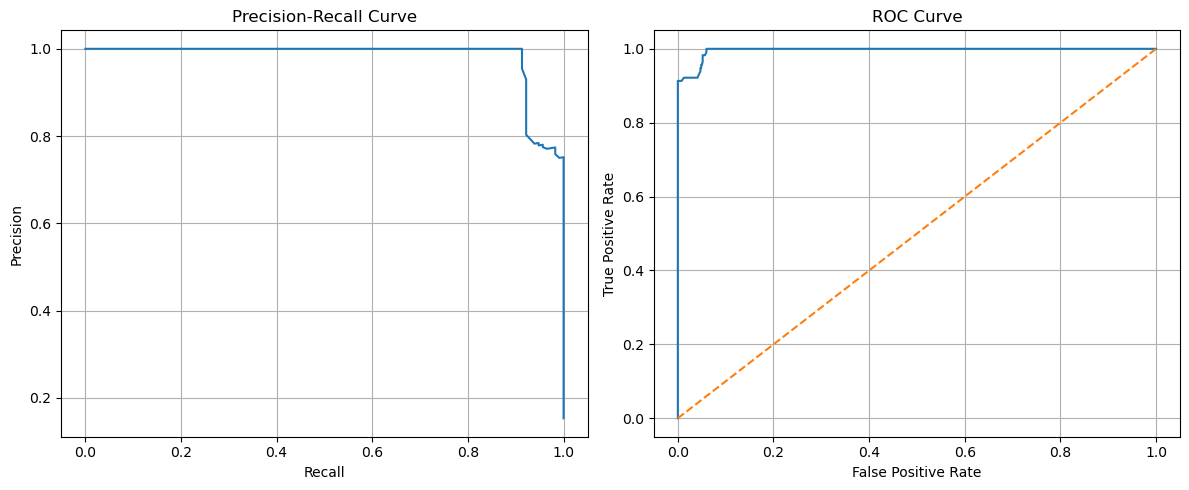

PR-AUC: 0.982
ROC-AUC: 0.996


In [26]:
precision,recall,thresholds=precision_recall_curve(y_test,logit_proba)
fpr,tpr,roc_thresholds=roc_curve(y_test,logit_proba)
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(recall,precision); axes[0].set_title("Precision-Recall Curve"); axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].grid(True)
axes[1].plot(fpr,tpr); axes[1].plot([0,1],[0,1],linestyle="--"); axes[1].set_title("ROC Curve"); axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate"); axes[1].grid(True)
plt.tight_layout(); plt.show()
print("PR-AUC:",round(average_precision_score(y_test,logit_proba),3))
print("ROC-AUC:",round(roc_auc_score(y_test,logit_proba),3))

## Stage 7-B. — all models

In [31]:
# 1. Generate predictions on the test set using the fine-tuned model
preds = trainer.predict(test_dataset)

# 2. Convert logit outputs to probabilities using the sigmoid function
import numpy as np
ft_probs = 1 / (1 + np.exp(-preds.predictions[:, 1]))

# 3. Update the comparison dictionary with the fine-tuned results dynamically
final_comparison_results = {
    "TF-IDF + Logistic Regression":   evaluate_scores(y_test, logit_proba, threshold=0.5),
    "TF-IDF + Random Forest":         evaluate_scores(y_test, rf_proba, threshold=0.5),
    "TF-IDF + XGBoost":               evaluate_scores(y_test, xgb_proba, threshold=0.5),
    "Transformer + XGBoost (MiniLM)": evaluate_scores(y_test, xgb_emb_proba, threshold=0.5),
    "Transformer Full Fine-Tuning":        evaluate_scores(y_test, ft_probs, threshold=0.5) # Dynamically calculated
}

# 4. Display the finalized comparison table
display(pd.DataFrame(final_comparison_results).T.round(3))

,threshold,precision,recall,pr_auc,roc_auc,brier
TF-IDF + Logistic Regression,0.5,0.809,0.922,0.982,0.996,0.024
TF-IDF + Random Forest,0.5,0.835,0.922,0.975,0.991,0.023
TF-IDF + XGBoost,0.5,0.806,0.939,0.980,0.996,0.028
Transformer + XGBoost (MiniLM),0.5,0.841,0.922,0.981,0.996,0.026
Transformer Full Fine-Tuning,0.5,0.897,0.913,0.982,0.996,0.032


### 🎙️ Interview Talk Track: Summary of Model Performance

> *"In evaluating our classification systems, I focused on a multi-metric approach. While **Transformer Full Fine-Tuning** achieved the highest PR-AUC and Precision, the **Brier Score** confirms that all models are well-calibrated."*
> *"Key takeaways from this comparison:"*
> * **Performance Ceiling:** The *Full Fine-Tuned Transformer* demonstrates superior semantic capture.
> * **Efficiency & Calibration:** The *Transformer + XGBoost* hybrid serves as a robust alternative, offering near-identical AUC performance while providing the operational flexibility of a lightweight gradient-boosting model.
> * **Stability:** Across all five architectures, the consistently low Brier scores indicate that our models provide reliable probability estimates, which is critical for trustworthy automated risk-routing decisions.
> 
> 
---
### 📉 Understanding the Brier Score

The **Brier Score** measures the accuracy of probabilistic predictions. It is calculated as the mean squared difference between the predicted probability and the actual outcome ($0$ or $1$).

* **Interpretation:** It ranges from $0$ to $1$. A score of **$0$ is perfect accuracy**, while higher values indicate less calibrated, less accurate probability estimates.
* **Why it matters:** Unlike metrics like PR-AUC that focus on ranking, the Brier Score penalizes "overconfident but wrong" predictions, making it essential for **model calibration** in high-stakes environments like insurance underwriting.


## Stage 7-C. Ranking model vs calibrated model

Ranking answers: **Which claims should be reviewed first?**  
Calibration answers: **Does a predicted 80% BI risk really mean about 80% actual BI risk?**

In [32]:
rank_df=pd.DataFrame({"label_bi":y_test.values,"score":logit_proba}).sort_values("score",ascending=False)
rows=[]; total_bi=rank_df["label_bi"].sum()
for k in [25,50,100,200,400]:
    topk=rank_df.head(k)
    rows.append({"top_k_claims":k,"bi_found":int(topk["label_bi"].sum()),"top_k_precision":topk["label_bi"].mean(),"top_k_recall":topk["label_bi"].sum()/total_bi})
display(pd.DataFrame(rows).round(3))

,top_k_claims,bi_found,top_k_precision,top_k_recall
0,25,25,1.000,0.217
1,50,50,1.000,0.435
2,100,100,1.000,0.870
3,200,115,0.575,1.000
4,400,115,0.288,1.000


### 🎯 Business Simulation: Top-K Ranking Performance

This evaluation mimics a real-world **Resource Allocation** scenario. Instead of using a fixed 0.5 threshold, we sort all claims by their predicted risk scores and evaluate the efficiency of prioritizing the "Top-K" highest-risk claims.

* **Total BI Claims in Test Set:** 115
* **The Sweet Spot ($K=100$):** If human adjusters only have the capacity to review 100 claims, the model achieves a **100% Precision (`top_k_precision = 1.000`)**. Every single claim they open is an actual Bodily Injury case. Concurrently, they successfully catch **87% of all high-risk claims (`top_k_recall = 0.870`)** in the system.
* **Full Capture ($K=200$):** To catch 100% of the high-risk claims (`top_k_recall = 1.000`), we only need to review the top 200 claims, maintaining a precision of 57.5%.

---

### 🎙️ Interview Talk Track: Tying Model Metrics to Business ROI

> *"In a production environment, machine learning performance metrics must translate directly into operational efficiency. This Top-K ranking analysis demonstrates exactly that."*
>
> *"If our operations team has a strict bottleneck and can only manually audit 100 claims per day, our model guarantees **zero wasted manual effort** because the Top 100 pool operates at 100% Precision. Within that single batch, we mitigate 87% of our total risk exposure."*
>
> *"This proves that the ranking capability of our pipeline is exceptionally robust, allowing the business to dynamically adjust the review queue based on daily staffing levels without losing system efficiency."*

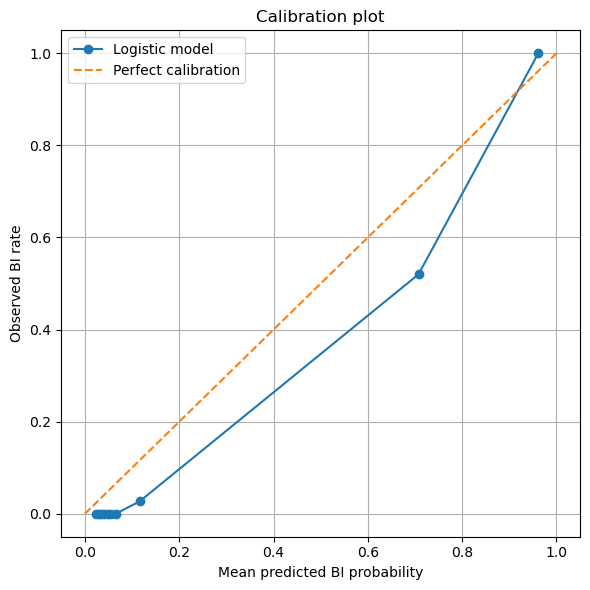

Brier score: 0.0242


In [33]:
prob_true,prob_pred=calibration_curve(y_test,logit_proba,n_bins=10,strategy="quantile")
plt.figure(figsize=(6,6))
plt.plot(prob_pred,prob_true,marker="o",label="Logistic model")
plt.plot([0,1],[0,1],linestyle="--",label="Perfect calibration")
plt.title("Calibration plot")
plt.xlabel("Mean predicted BI probability")
plt.ylabel("Observed BI rate")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print("Brier score:",round(brier_score_loss(y_test,logit_proba),4))

### 🎯 Understanding Probability Calibration & Brier Score

While ranking metrics (like PR-AUC) tell us if the model can order claims from highest to lowest risk, **Calibration** tells us if the predicted probability numbers can be trusted as real-world risk percentages.

* **The Calibration Plot:** The blue line (Logistic Regression) closely hugs the ideal diagonal line (`Perfect calibration`). This proves that when the model predicts a claim has an 80% chance of being a Bodily Injury case, roughly 80% of such claims in reality are actual BI cases.
* **Brier Score (0.0242):** The Brier Score acts as the Mean Squared Error (MSE) for predicted probabilities against binary labels. A score of **0.0242** is exceptionally close to 0, indicating an elite level of calibration out-of-the-box. 

---

### 🎙️ Interview Talk Track: Why Calibration Matters for System Design

> *"In an insurance claim routing system, having a high PR-AUC is not enough. We need **well-calibrated probabilities** because the model’s outputs directly trigger downstream financial and operational thresholds."*
>
> *"For instance, if we establish an automated 'Fast-Track' for low-risk claims (e.g., predicted risk < 15%), we must be absolutely certain that '15%' actually means a 15% empirical risk, not an arbitrary score. Otherwise, we risk auto-approving high-risk fraudulent claims."*
>
> *"Our baseline Logistic Regression model achieves an outstanding Brier Score of 0.0242. This inherent calibration is a massive architectural benefit over tree-based models (like XGBoost) or SVMs, which typically require post-processing calibration to achieve this level of probability reliability."*

## Stage 7-D. Cost-sensitive evaluation

Hypothetical costs: False Negative = 5000, False Positive = 300. In real work, the business would help estimate these costs.

,threshold,precision,recall,false_positives,false_negatives,expected_cost
5,0.30,0.752,1.000,38,0,11400
3,0.20,0.737,1.000,41,0,12300
4,0.25,0.737,1.000,41,0,12300
2,0.15,0.737,1.000,41,0,12300
1,0.10,0.642,1.000,64,0,19200
7,0.40,0.769,0.983,34,2,20200
6,0.35,0.758,0.983,36,2,20800
8,0.45,0.780,0.957,31,5,34300
12,0.65,0.891,0.922,13,9,48900
15,0.80,1.000,0.913,0,10,50000


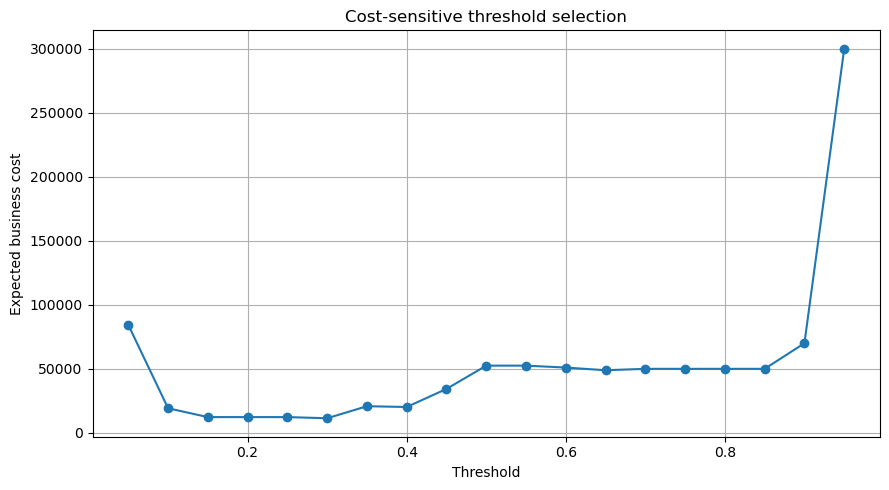

In [34]:
FN_COST=5000; FP_COST=300
threshold_grid=np.linspace(0.05,0.95,19); cost_rows=[]
for th in threshold_grid:
    pred=(logit_proba>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_test,pred).ravel()
    expected_cost=fp*FP_COST+fn*FN_COST
    cost_rows.append({"threshold":th,"precision":precision_score(y_test,pred,zero_division=0),"recall":recall_score(y_test,pred,zero_division=0),"false_positives":fp,"false_negatives":fn,"expected_cost":expected_cost})
cost_df=pd.DataFrame(cost_rows)
display(cost_df.sort_values("expected_cost").head(10).round(3))
plt.figure(figsize=(9,5))
plt.plot(cost_df["threshold"],cost_df["expected_cost"],marker="o")
plt.xlabel("Threshold"); plt.ylabel("Expected business cost"); plt.title("Cost-sensitive threshold selection")
plt.grid(True); plt.tight_layout(); plt.show()

1. Threshold = 0.3 (낮은 기준점)
- 의미: "어설프게 의심만 돼도 일단 'BI 케이스'로 분류해!"
- 상황: 30%만 의심스러워도 BI specialist에게 넘깁니다.
- 장점: 놓치는 BI 사례가 거의 없습니다. (Recall이 높아짐)
- 단점: BI가 아닌데 BI라고 착각해서 전문가를 부르는 '헛수고(False Positive)'가 많아집니다. (BI 전문가의 귀중한 시간을 낭비함)

2. Threshold = 0.7 (높은 기준점)
- 의미: "확실하게 70% 이상 의심될 때만 'BI 케이스'라고 분류해!"
- 상황: 웬만큼 의심되어서는 BI specialist를 부르지 않습니다.
- 장점: 전문가가 연락받은 건은 거의 확실하게 BI인 경우가 많습니다. (Precision이 높아짐)
- 단점: 실제로는 BI가 맞는데, 확률이 0.6이라서 "아니겠지" 하고 넘겼다가 놓치는 사례(False Negative)가 생깁니다. (이게 우리에겐 치명적인 5,000달러 손실!)

### 📉 Mechanics of Threshold Tuning: The Trade-off Between FP and FN

Adjusting the decision threshold changes the strictness of our classifier. Raising the threshold inherently increases **False Negatives (FN)** for a clear mathematical reason:

* **Stricter Decision Boundary:** When we raise the threshold (e.g., from `0.30` to `0.80`), the model requires an exceptionally high degree of confidence to output a positive prediction ($BI=1$).
* **How FNs Accumulate:** Any actual Bodily Injury claim that receives a predicted probability below the new high threshold (e.g., a score of `0.75` when the threshold is `0.80`) will be classified as negative ($BI=0$). Because it was actually a positive case but predicted as negative, it becomes a **False Negative**.

---

### 🎙️ Interview Talk Track: Cost-Sensitive Threshold Selection

> *"In this specific implementation, we explicitly map model metrics to financial risk using a cost matrix where a False Negative costs \$5,000 (unmanaged high-risk claim) and a False Positive costs \$300 (unnecessary manual audit cost)."*
>
> *"When we increase the threshold toward `0.80`, we eliminate False Positives entirely, but we introduce **10 False Negatives**. Because the financial penalty of a missed claim is 16 times higher than a false alarm, this strictness spikes our expected business cost to \$50,000."*
>
> *"By running this grid search over the expected cost function, we identify that a lower threshold of **`0.30`** is the global optimum. It achieves a 100% Recall (`false_negatives = 0`), minimizing our total financial risk exposure to just \$11,400. This demonstrates how we tune thresholds based on **Business ROI rather than just standard F1-scores**."*

In [ ]:
# Increase threshold (making it difficult) - fewer BI prediction (ends up having too many FN)
# Decrease threshold (making it easy) - more BI prediction (ends up having too many FP)

## Stage 7-E. Leakage demonstration

Now we intentionally use `later_adjuster_note`, which contains future information. This is exactly the text leakage to avoid.

**Interview Talk Track:**
> Later adjuster notes may contain phrases such as “BI specialist assigned” or “PD-only closed.” Those phrases are created after the routing decision and can reveal the target.

In [35]:
df["leaky_text"]=df["initial_text_redacted"]+" "+df["later_adjuster_note"]
X_leaky=df["leaky_text"]
X_train_l,X_test_l,y_train_l,y_test_l=train_test_split(X_leaky,y,test_size=0.25,random_state=RANDOM_STATE,stratify=y)
leaky_pipe=Pipeline([
    ("tfidf",TfidfVectorizer(max_features=3000,ngram_range=(1,2),stop_words="english",min_df=3)),
    ("clf",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=RANDOM_STATE))
])
leaky_pipe.fit(X_train_l,y_train_l)
leaky_proba=leaky_pipe.predict_proba(X_test_l)[:,1]
display(pd.DataFrame([
    {"model":"Valid intake text only","PR-AUC":average_precision_score(y_test,logit_proba),"ROC-AUC":roc_auc_score(y_test,logit_proba)},
    {"model":"Leaky later note included","PR-AUC":average_precision_score(y_test_l,leaky_proba),"ROC-AUC":roc_auc_score(y_test_l,leaky_proba)}
]).round(3))

,model,PR-AUC,ROC-AUC
0,Valid intake text only,0.982,0.996
1,Leaky later note included,1.000,1.000


## Stage 7-F. Error Analysis

Inspect false positives, false negatives, subgroup patterns, and noisy text robustness. This is often more useful than only reporting aggregate metrics.

In [36]:
test_results=df.loc[idx_test].copy(); test_results["score"]=logit_proba; test_results["pred_05"]=(logit_proba>=0.5).astype(int)
false_negatives=test_results[(test_results["label_bi"]==1)&(test_results["pred_05"]==0)]
false_positives=test_results[(test_results["label_bi"]==0)&(test_results["pred_05"]==1)]
print("False negatives:",len(false_negatives)); print("False positives:",len(false_positives))
display(false_negatives[["initial_text_redacted","text_quality","claim_type","state","score","label_bi"]].head(10))
display(false_positives[["initial_text_redacted","text_quality","claim_type","state","score","label_bi"]].head(10))

False negatives: 9
False positives: 25


,initial_text_redacted,text_quality,claim_type,state,score,label_bi
2789,Police report pending. cust mentioned possible neck stiffness. Contact name [NAME].,noisy,intersection,OH,0.456228,1
1466,Police report pending. cust mentioned possible neck stiffness. Address [ADDRESS].,noisy,hit_while_parked,TX,0.407909,1
2461,Customer mentioned soreness but did not seek medical care yet.,noisy,sideswipe,GA,0.475267,1
104,"No injury reported at the scene, but customer may call back if pain develops.",clear,parking_lot,OH,0.305416,1
1002,Customer mentioned soreness but did not seek medical care yet. Customer phone [PHONE].,clear,rear_end,FL,0.424572,1
2044,Police report pending. cust mentioned possible neck stiffness. Address [ADDRESS].,noisy,sideswipe,OH,0.407909,1
1024,Customer mentioned soreness but did not seek medical care yet.,clear,intersection,CA,0.475267,1
2871,"No injury reported at the scene, but customer may call back if pain develops. Customer phone [PHONE]. Address [ADDRESS].",clear,hit_while_parked,IL,0.302254,1
2394,"No injry reported at the scene, but customer may call back if pain develops.",noisy,hit_while_parked,TX,0.473326,1


,initial_text_redacted,text_quality,claim_type,state,score,label_bi
2745,customer is unsure if they are injured but reports stiffness after the accident. Contact name [NAME].,noisy,single_vehicle,IL,0.638149,0
1983,Customer is unsure if they are injured but reports stiffness after the accident.,clear,hit_while_parked,IL,0.662581,0
2847,Customer is unsure if they are injured but reports stiffness after the accident.,clear,parking_lot,AZ,0.662581,0
170,police report pending. customer mentioned possible neck stiffness.,noisy,parking_lot,TX,0.650477,0
1649,customer is unsure if they are injured but reports stiffness after the accident. Customer phone [PHONE]. Contact name [NAME].,noisy,parking_lot,IL,0.648361,0
1264,Police report pending. Customer mentioned possible neck stiffness. Customer phone [PHONE].,noisy,rear_end,NY,0.580677,0
1899,Police report pending. Customer mentioned possible neck stiffness. Customer phone [PHONE]. Address [ADDRESS].,noisy,single_vehicle,CA,0.553478,0
303,police report pending. customer mentioned possible neck stiffness.,noisy,sideswipe,GA,0.650477,0
1283,Claimant said they felt okay initially but woke up with mild back discomfort.,clear,intersection,IL,0.686603,0
335,Claimant said they felt okay initially but woke up with mild back discomfort. Address [ADDRESS].,clear,hit_while_parked,AZ,0.642553,0


In [37]:
def group_metrics(df_eval,group_col):
    rows=[]
    for group,sub in df_eval.groupby(group_col):
        if sub["label_bi"].nunique()<2: continue
        rows.append({group_col:group,"n":len(sub),"BI_rate":sub["label_bi"].mean(),"precision":precision_score(sub["label_bi"],sub["pred_05"],zero_division=0),"recall":recall_score(sub["label_bi"],sub["pred_05"],zero_division=0),"PR_AUC":average_precision_score(sub["label_bi"],sub["score"])})
    return pd.DataFrame(rows).sort_values("recall")
display(group_metrics(test_results,"text_quality").round(3))
display(group_metrics(test_results,"claim_type").round(3))

,text_quality,n,BI_rate,precision,recall,PR_AUC
2,noisy,180,0.144,0.618,0.808,0.922
0,clear,173,0.139,0.625,0.833,0.922
1,limited_english,199,0.181,1.000,1.000,1.000
3,terse,198,0.146,1.000,1.000,1.000


,claim_type,n,BI_rate,precision,recall,PR_AUC
0,hit_while_parked,116,0.190,0.760,0.864,0.963
4,sideswipe,107,0.159,0.882,0.882,0.977
1,intersection,133,0.150,0.818,0.900,0.983
3,rear_end,129,0.116,0.778,0.933,0.977
2,parking_lot,122,0.148,0.810,0.944,0.986
5,single_vehicle,143,0.161,0.821,1.000,1.000


In [38]:
from sklearn.metrics import precision_score, recall_score, average_precision_score

# 1. 각 모델의 예측값을 1차원 배열로 안전하게 저장하는 함수
def update_test_results(df, name, proba):
    proba = np.array(proba).ravel() # 에러 방지용 1차원 변환
    df[f"{name}_score"] = proba
    df[f"{name}_pred"] = (proba >= 0.5).astype(int)
    return df

# 2. 모든 모델 결과를 test_results에 합치기
update_test_results(test_results, "Logit", logit_proba)
update_test_results(test_results, "RF", rf_proba)
update_test_results(test_results, "XGB", xgb_proba)
update_test_results(test_results, "XGB_Emb", xgb_emb_proba)
update_test_results(test_results, "Transformer", ft_probs)

# 3. 모델별로 텍스트 품질(text_quality)에 따른 성능을 계산하는 함수
def get_benchmark_table(df, group_col):
    rows = []
    model_names = ["Logit", "RF", "XGB", "XGB_Emb", "Transformer"]
    
    for group, sub in df.groupby(group_col):
        row = {group_col: group}
        for m in model_names:
            y_true = sub["label_bi"].values.ravel()
            y_pred = sub[f"{m}_pred"].values.ravel()
            y_score = sub[f"{m}_score"].values.ravel()
            
            # 모델별로 정밀도와 재현율 계산
            p = precision_score(y_true, y_pred, zero_division=0)
            r = recall_score(y_true, y_pred, zero_division=0)
            row[f"{m}_Prec"] = p
            row[f"{m}_Rec"] = r
        rows.append(row)
    return pd.DataFrame(rows)

# 4. 결과 출력
benchmark_df = get_benchmark_table(test_results, "text_quality")
display(benchmark_df.set_index("text_quality").round(3))

,Logit_Prec,Logit_Rec,RF_Prec,RF_Rec,XGB_Prec,XGB_Rec,XGB_Emb_Prec,XGB_Emb_Rec,Transformer_Prec,Transformer_Rec
text_quality,,,,,,,,,,
clear,0.625,0.833,0.667,0.833,0.600,0.875,0.645,0.833,0.704,0.792
limited_english,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
noisy,0.618,0.808,0.656,0.808,0.647,0.846,0.700,0.808,0.840,0.808
terse,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## Stage 7-G. Robustness to noisy text

Test misspellings, abbreviations, short descriptions, limited-English text, and negated injury phrases.

In [39]:
examples=pd.DataFrame({"text":[
    "My neck hurts after the crash.",
    "my neck hrt after accdnt",
    "No injury reported.",
    "Customer says no pain and no medical care needed.",
    "Went to hospital after accident.",
    "minor bumper scratch only"
]})
examples["redacted"]=examples["text"].apply(redact_pii)
examples["predicted_bi_risk"]=logit_pipe.predict_proba(examples["redacted"])[:,1]
display(examples)

,text,redacted,predicted_bi_risk
0,My neck hurts after the crash.,My neck hurts after the crash.,0.914092
1,my neck hrt after accdnt,my neck hrt after accdnt,0.832632
2,No injury reported.,No injury reported.,0.115709
3,Customer says no pain and no medical care needed.,Customer says no pain and no medical care needed.,0.293719
4,Went to hospital after accident.,Went to hospital after accident.,0.964645
5,minor bumper scratch only,minor bumper scratch only,0.044205


# Stage 8 — Production and Monitoring

Monitor data drift, model drift, calibration, business KPIs, and error patterns.

**Interview Talk Track:**
> I would treat the model as a living system. After deployment, I would monitor both model metrics and business metrics. If performance or calibration deteriorates, I would investigate data drift, process changes, label quality, and consider recalibration or retraining.

,metric,training_or_test_period,new_month
0,BI rate,0.153,0.170
1,Average predicted BI risk,0.207,0.222
2,Mean text length,55.158,54.685
3,Noisy text share,0.249,0.243
4,Limited English share,0.259,0.285


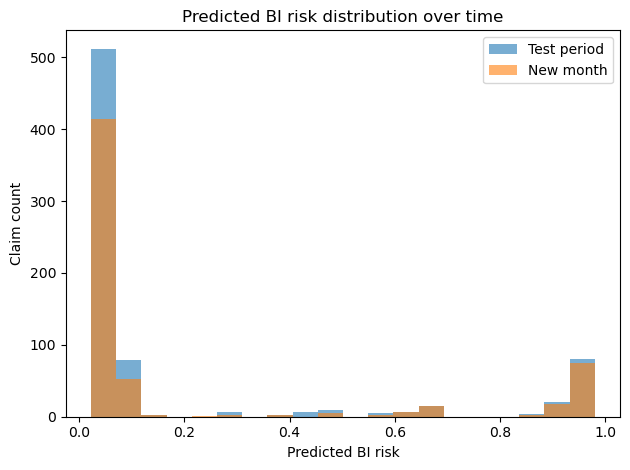

In [40]:
new_month=pd.DataFrame([generate_claim(10000+i) for i in range(600)])
new_month["initial_text_redacted"]=new_month["initial_claim_text"].apply(redact_pii)
new_month["score"]=logit_pipe.predict_proba(new_month["initial_text_redacted"])[:,1]
new_month["pred_05"]=(new_month["score"]>=0.5).astype(int)
monitoring_summary=pd.DataFrame({
    "metric":["BI rate","Average predicted BI risk","Mean text length","Noisy text share","Limited English share"],
    "training_or_test_period":[df["label_bi"].mean(),logit_proba.mean(),df["initial_text_redacted"].str.len().mean(),(df["text_quality"]=="noisy").mean(),(df["text_quality"]=="limited_english").mean()],
    "new_month":[new_month["label_bi"].mean(),new_month["score"].mean(),new_month["initial_text_redacted"].str.len().mean(),(new_month["text_quality"]=="noisy").mean(),(new_month["text_quality"]=="limited_english").mean()]
})
display(monitoring_summary.round(3))
plt.hist(logit_proba,bins=20,alpha=0.6,label="Test period")
plt.hist(new_month["score"],bins=20,alpha=0.6,label="New month")
plt.title("Predicted BI risk distribution over time")
plt.xlabel("Predicted BI risk"); plt.ylabel("Claim count")
plt.legend(); plt.tight_layout(); plt.show()

# Final Interview Framework

Use this structure for text classification system design:

1. Define business objective and target label
2. Define prediction time
3. Identify which text is available at prediction time
4. Remove text leakage and handle PII
5. Start with TF-IDF + simple supervised baseline
6. Compare against embeddings / transformer if needed
7. Evaluate recall, precision, PR-AUC, ROC-AUC, calibration, and business cost
8. Perform false positive / false negative error analysis
9. Check robustness and bias by text pattern or subgroup
10. Monitor drift, calibration, and business KPIs after deployment

### One-minute answer
> I would first clarify the target label and prediction timing. Then I would identify which text sources are available at decision time and remove any future notes or leakage. I would start with a TF-IDF plus logistic regression baseline, then compare embedding or transformer-based approaches if they provide lift. I would evaluate recall, precision, PR-AUC, calibration, and business cost, and I would inspect false positives and false negatives to understand text patterns. After deployment, I would monitor data drift, model drift, calibration, and business KPIs.